In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Preprocess dataset: label encoding and wide format transformation

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load the dataset
df = pd.read_csv('/kaggle/input/glucemia-dataset/combined_glucemia_dataset.csv')

# Sample data creation for demonstration
# df = pd.read_csv('your_original_dataset.csv')  # Load your dataset

# Create a new ID column that increments continuously
# Assuming 'ID' is the existing column with repeating IDs
# Remove the original ID column
df = df.drop(columns=['ID'])

# Create a new ID column that increments every 24 entries
df['ID'] = (df.index // 24) + 1  # New IDs starting from 1


# Define custom mappings
condition_mapping = {
    'No Diabetes': 0,
    'Prediabetes': 1,
    'Type 2 Diabetes': 2,
    'Gestational Diabetes': 3
}

gender_mapping = {
    'Female': 0,
    'Male': 1
}

df['Condition'] = df['Condition'].map(condition_mapping)
df['Gender'] = df['Gender'].map(gender_mapping)

df.rename(columns={'Condition': 'Diabetes_Status'}, inplace=True)

# Function to convert timestamp to total seconds
def convert_to_seconds(timestamp):
    hours, minutes, seconds = map(int, timestamp.split(':'))
    return hours * 3600 + minutes * 60 + seconds

df['Timestamp'] = df['Timestamp'].apply(convert_to_seconds)

scaler = MinMaxScaler()

df['Timestamp'] = scaler.fit_transform(df[['Timestamp']])
df['Glucose_mg/dL'] = scaler.fit_transform(df[['Glucose_mg/dL']])

# Display the updated DataFrame to verify the changes
print("Updated DataFrame with New IDs:")
print(df.head(48))  # Show the first 48 entries to illustrate the ID counting



Updated DataFrame with New IDs:
    Diabetes_Status  Gender  Timestamp  Glucose_mg/dL  HbA1c (%)  ID
0                 0       0   0.000000       0.027933       5.12   1
1                 0       0   0.043478       0.039106       5.12   1
2                 0       0   0.086957       0.083799       5.12   1
3                 0       0   0.130435       0.039106       5.12   1
4                 0       0   0.173913       0.055866       5.12   1
5                 0       0   0.217391       0.050279       5.12   1
6                 0       0   0.260870       0.061453       5.12   1
7                 0       0   0.304348       0.055866       5.12   1
8                 0       0   0.347826       0.167598       5.12   1
9                 0       0   0.391304       0.139665       5.12   1
10                0       0   0.434783       0.279330       5.12   1
11                0       0   0.478261       0.111732       5.12   1
12                0       0   0.521739       0.307263       5.12   1
13

In [2]:
# Initialize a dictionary to store separate DataFrames for each ID
id_dataframes = {}

# Loop through unique New_IDs
for unique_id in df['ID'].unique():
    # Filter the DataFrame for the current New_ID
    id_dataframe = df[df['ID'] == unique_id]
    
    # Store the DataFrame in the dictionary
    id_dataframes[unique_id] = id_dataframe.reset_index(drop=True)

# Example of accessing the DataFrame for a specific New_ID
print("DataFrame for ID 1:")
print(id_dataframes[1])

print("\nDataFrame for ID 2:")
print(id_dataframes[2])





DataFrame for ID 1:
    Diabetes_Status  Gender  Timestamp  Glucose_mg/dL  HbA1c (%)  ID
0                 0       0   0.000000       0.027933       5.12   1
1                 0       0   0.043478       0.039106       5.12   1
2                 0       0   0.086957       0.083799       5.12   1
3                 0       0   0.130435       0.039106       5.12   1
4                 0       0   0.173913       0.055866       5.12   1
5                 0       0   0.217391       0.050279       5.12   1
6                 0       0   0.260870       0.061453       5.12   1
7                 0       0   0.304348       0.055866       5.12   1
8                 0       0   0.347826       0.167598       5.12   1
9                 0       0   0.391304       0.139665       5.12   1
10                0       0   0.434783       0.279330       5.12   1
11                0       0   0.478261       0.111732       5.12   1
12                0       0   0.521739       0.307263       5.12   1
13            

In [3]:
# Initialize a dictionary to store the wide format DataFrames
wide_id_dataframes = {}

# Loop through each DataFrame in the id_dataframes dictionary
for unique_id, id_df in id_dataframes.items():
    # Pivot the DataFrame to wide format
    wide_df = id_df.pivot_table(index=['ID', 'Diabetes_Status', 'Gender', 'HbA1c (%)'], 
                                 columns='Timestamp', 
                                 values='Glucose_mg/dL')

    # Flatten the MultiIndex columns and rename them
    wide_df.columns = [f'Glucose_Reading{i + 1}' for i in range(len(wide_df.columns))]  # Start count at 1
    wide_df.reset_index(inplace=True)  # Reset index to turn MultiIndex into regular columns
    
    # Store the wide DataFrame in the dictionary
    wide_id_dataframes[unique_id] = wide_df

# Example of accessing the wide DataFrame for a specific ID
print("Wide DataFrame for ID 1:")
print(wide_id_dataframes[1])

# Combine all DataFrames in wide_id_dataframes into one DataFrame
combined_wide_df = pd.concat(wide_id_dataframes.values(), ignore_index=True)

# Display the combined DataFrame
print("Combined Wide DataFrame:")
print(combined_wide_df)

Wide DataFrame for ID 1:
   ID  Diabetes_Status  Gender  HbA1c (%)  Glucose_Reading1  Glucose_Reading2  \
0   1                0       0       5.12          0.027933          0.039106   

   Glucose_Reading3  Glucose_Reading4  Glucose_Reading5  Glucose_Reading6  \
0          0.083799          0.039106          0.055866          0.050279   

   ...  Glucose_Reading15  Glucose_Reading16  Glucose_Reading17  \
0  ...           0.318436           0.134078            0.24581   

   Glucose_Reading18  Glucose_Reading19  Glucose_Reading20  Glucose_Reading21  \
0           0.139665           0.301676           0.134078           0.162011   

   Glucose_Reading22  Glucose_Reading23  Glucose_Reading24  
0           0.318436           0.201117           0.122905  

[1 rows x 28 columns]
Combined Wide DataFrame:
          ID  Diabetes_Status  Gender  HbA1c (%)  Glucose_Reading1  \
0          1                0       0       5.12          0.027933   
1          2                0       0       4.65 

In [4]:
combined_wide_df.to_csv('corrected_glucemia_dataset.csv')

In [8]:
# Step 1: Prepare features and targets
features = combined_wide_df.filter(like='Glucose_Reading').values  # Get all glucose readings
targets = combined_wide_df['Diabetes_Status'].values  # Get target variable

# Step 2: Reshape features for LSTM
num_patients = combined_wide_df.shape[0]  # Number of patients
timesteps = 24  # Assuming you have 24 glucose readings
num_features = 1  # Each glucose reading is a separate feature

print(f"Number of Patients: {num_patients}")
print(f"Number of Features: {num_features}")

# Reshape to (num_patients, timesteps, num_features)
X_reshaped = features.reshape(num_patients, timesteps, num_features)  # Each glucose reading as a separate feature

# Now you can split your data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, targets, test_size=0.3, random_state=42)

# Print shapes of your datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Number of Patients: 70000
Number of Features: 1
X_train shape: (49000, 24, 1)
y_train shape: (49000,)
X_test shape: (21000, 24, 1)
y_test shape: (21000,)


Epoch 1/100


/opt/conda/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


1532/1532 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.2714 - loss: 1.4102 - val_accuracy: 0.2894 - val_loss: 1.3618 - learning_rate: 1.0000e-05
Epoch 2/100
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3005 - loss: 1.3675 - val_accuracy: 0.2894 - val_loss: 1.2929 - learning_rate: 1.0000e-05
Epoch 3/100
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3644 - loss: 1.2992 - val_accuracy: 0.5726 - val_loss: 1.1277 - learning_rate: 1.0000e-05
Epoch 4/100
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6519 - loss: 1.1119 - val_accuracy: 0.7122 - val_loss: 0.8562 - learning_rate: 1.0000e-05
Epoch 5/100
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7115 - loss: 0.9037 - val_accuracy: 0.7274 - val_loss: 0.7336 - learning_rate: 1.0000e-05
Epoch 6/100
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7060 - loss: 0.8111 - val_accuracy: 0.7557 - val_loss: 0.6618 - learning_rate: 1.0000e-05
Epoch 7/100
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/s

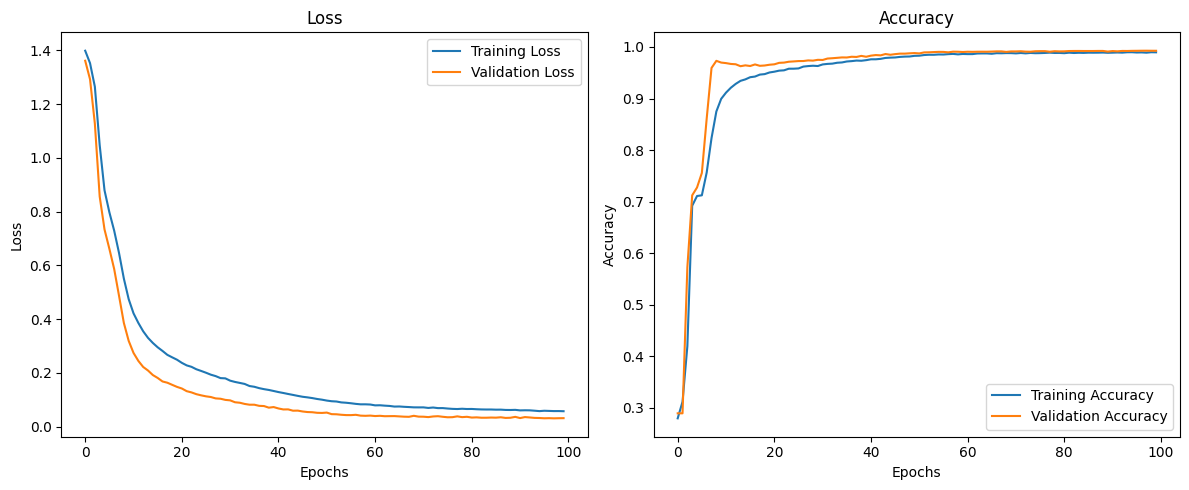

In [36]:
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from sklearn.utils import class_weight
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

# Specify the output path
output_path = '/kaggle/working/'

# Set a lower initial learning rate
learning_rate = 0.00001  # You can adjust this value
optimizer = Adam(learning_rate=learning_rate)

# Step 1: One-hot encode the targets
encoder = OneHotEncoder(sparse=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

# Step 2: Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

num_classes = y_train_onehot.shape[1]

# Define the model
model = Sequential()
model.add(Input(shape=(timesteps, num_features)))
model.add(LSTM(20, kernel_regularizer='l2', return_sequences=False))  # Single LSTM layer with L2 regularization
model.add(Dropout(0.5))  # Increased dropout
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping and model checkpointing
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath=f'{output_path}best_model.keras', save_best_only=True, monitor='val_loss')

# Reduce learning rate on plateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-10)

# Train the model with class weights
history = model.fit(X_train, y_train_onehot, epochs=100, batch_size=32,
                    validation_data=(X_test, y_test_onehot),
                    class_weight=class_weight_dict,
                    callbacks=[early_stopping, model_checkpoint, reduce_lr])  # Add early stopping, checkpoint, and learning rate reduction

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_onehot)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Save the figure
plt.savefig(f'{output_path}Training_Validation_Accuracy_for_CGM_Model.png')
plt.tight_layout()
plt.show()


In [37]:
# Get predicted probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# You can then evaluate accuracy based on these predicted classes
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5947
           1       0.99      0.98      0.99      6012
           2       1.00      1.00      1.00      6078
           3       0.97      0.98      0.97      2963

    accuracy                           0.99     21000
   macro avg       0.99      0.99      0.99     21000
weighted avg       0.99      0.99      0.99     21000



In [38]:
model.save('cgm_model.keras')